# 11: CatBoost

## 1. Imports

In [1]:
import sys
import ast

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, ParameterSampler, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
from catboost import CatBoostClassifier

from src.config import (
    TRAIN_CLEAN_PATH, TRAIN_FEATURED_PATH, SPLIT_MANIFEST_PATH,
    MODELS_DIR, RESULTS_DIR, TARGET, ID_COLUMN, RANDOM_STATE, PROJECT_ROOT,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## 2. Load Data and Create Holdout Split

In [2]:
clean = pd.read_csv(TRAIN_CLEAN_PATH)
featured = pd.read_csv(TRAIN_FEATURED_PATH)
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)

train_ids = set(manifest.loc[manifest["Split"] == "train", ID_COLUMN])
holdout_ids = set(manifest.loc[manifest["Split"] == "test", ID_COLUMN])

def split_by_manifest(df):
    development = df[df[ID_COLUMN].isin(train_ids)].sort_values(ID_COLUMN).reset_index(drop=True)
    holdout = df[df[ID_COLUMN].isin(holdout_ids)].sort_values(ID_COLUMN).reset_index(drop=True)
    return development, holdout

clean_dev, clean_holdout = split_by_manifest(clean)
featured_dev, featured_holdout = split_by_manifest(featured)

print("Development rows:", len(clean_dev))
print("Holdout rows:", len(clean_holdout))
print("Development attrition rate:", f"{clean_dev[TARGET].mean():.1%}")
print("Holdout attrition rate:", f"{clean_holdout[TARGET].mean():.1%}")

Development rows: 846
Holdout rows: 212
Development attrition rate: 16.9%
Holdout attrition rate: 17.0%


## 3. Prepare CatBoost Features

In [3]:
def prepare_catboost_features(df):
    X = df.drop(columns=[TARGET, ID_COLUMN]).copy()
    categorical_columns = [
        column for column in X.columns
        if not pd.api.types.is_numeric_dtype(X[column])
    ]
    for column in categorical_columns:
        X[column] = X[column].fillna("Missing").astype(str)
    return X, categorical_columns

## 4. Reusable 5-fold CatBoost evaluation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_catboost_cv(development_df, params=None, return_oof=False):
    params = {} if params is None else params.copy()
    X, categorical_columns = prepare_catboost_features(development_df)
    y = development_df[TARGET].reset_index(drop=True)

    train_pr = []
    valid_pr = []
    valid_roc = []
    oof_probability = np.zeros(len(y))

    for train_index, valid_index in cv.split(X, y):
        X_train, X_valid = X.iloc[train_index].copy(), X.iloc[valid_index].copy()
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="PRAUC:type=Classic",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
            **params,
        )
        model.fit(X_train, y_train, cat_features=categorical_columns)

        train_probability = model.predict_proba(X_train)[:, 1]
        valid_probability = model.predict_proba(X_valid)[:, 1]

        train_pr.append(average_precision_score(y_train, train_probability))
        valid_pr.append(average_precision_score(y_valid, valid_probability))
        valid_roc.append(roc_auc_score(y_valid, valid_probability))
        oof_probability[valid_index] = valid_probability

    result = {
        "mean_train_pr_auc": np.mean(train_pr),
        "mean_test_pr_auc": np.mean(valid_pr),
        "std_test_pr_auc": np.std(valid_pr),
        "mean_test_roc_auc": np.mean(valid_roc),
        "std_test_roc_auc": np.std(valid_roc),
    }
    if return_oof:
        result["oof_probability"] = oof_probability
    return result

## 5. Compare Features (Original v. Engineered)

In [5]:
baseline_params = {
    "iterations": 500,
    "learning_rate": 0.05,
    "depth": 5,
    "l2_leaf_reg": 5.0,
}

comparison_rows = []
for feature_set_name, development_df in [
    ("Original cleaned features", clean_dev),
    ("Engineered candidate features", featured_dev),
]:
    print(f"Evaluating: {feature_set_name}...")

    result = evaluate_catboost_cv(
        development_df,
        baseline_params,
    )

    print(
        f"PR-AUC: {result['mean_test_pr_auc']:.4f}"
    )

    comparison_rows.append({
        "feature_set": feature_set_name,
        "cv_roc_auc_mean": result["mean_test_roc_auc"],
        "cv_roc_auc_std": result["std_test_roc_auc"],
        "cv_pr_auc_mean": result["mean_test_pr_auc"],
        "cv_pr_auc_std": result["std_test_pr_auc"],
    })

feature_comparison = pd.DataFrame(comparison_rows)
feature_comparison.round(4)

Evaluating: Original cleaned features...
PR-AUC: 0.5771
Evaluating: Engineered candidate features...
PR-AUC: 0.5715


,feature_set,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Original cleaned features,0.8008,0.0493,0.5771,0.0431
1,Engineered candidate features,0.8153,0.0412,0.5715,0.0650


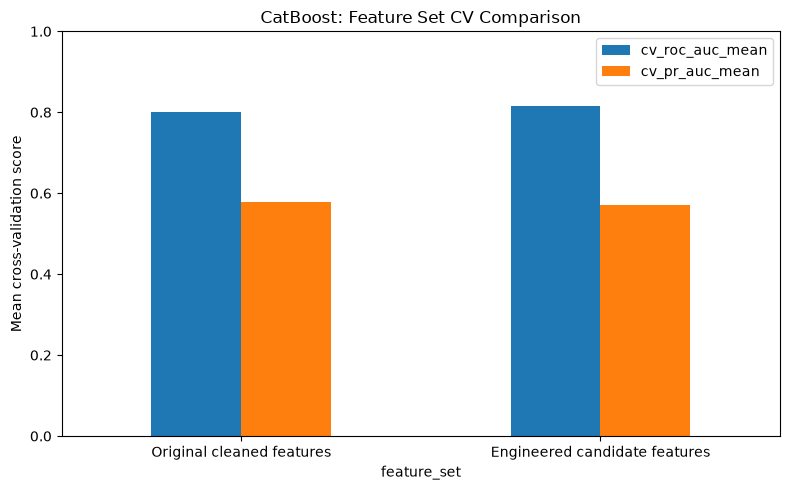

In [6]:
feature_comparison.set_index("feature_set")[["cv_roc_auc_mean", "cv_pr_auc_mean"]].plot(
    kind="bar", figsize=(8, 5)
)
plt.title("CatBoost: Feature Set CV Comparison")
plt.ylabel("Mean cross-validation score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
selected_name = feature_comparison.sort_values("cv_pr_auc_mean", ascending=False).iloc[0]["feature_set"]
print("Selected feature set:", selected_name)

if selected_name == "Engineered candidate features":
    development, holdout = featured_dev, featured_holdout
else:
    development, holdout = clean_dev, clean_holdout

X_dev, categorical_columns = prepare_catboost_features(development)
y_dev = development[TARGET]
X_holdout, _ = prepare_catboost_features(holdout)
y_holdout = holdout[TARGET]
negative_positive_ratio = (y_dev == 0).sum() / (y_dev == 1).sum()

print("Categorical features:", len(categorical_columns))
print("Negative / positive ratio:", round(negative_positive_ratio, 2))

Selected feature set: Original cleaned features
Categorical features: 7
Negative / positive ratio: 4.92


## 6. Tune CatBoost

In [8]:
parameter_space = {
    "iterations": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "depth": [3, 4, 5, 6, 7],
    "l2_leaf_reg": [1.0, 3.0, 5.0, 10.0, 20.0],
    "random_strength": [0.0, 0.5, 1.0, 2.0, 5.0],
    "bagging_temperature": [0.0, 0.5, 1.0, 2.0, 5.0],
    "border_count": [32, 64, 128],
    "class_weights": [
        None,
        [1.0, negative_positive_ratio / 2],
        [1.0, negative_positive_ratio],
    ],
}

sampled_parameters = list(ParameterSampler(parameter_space, n_iter=40, random_state=RANDOM_STATE))
tuning_rows = []

for run_number, params in enumerate(sampled_parameters, start=1):
    result = evaluate_catboost_cv(development, params=params)
    tuning_rows.append({"run": run_number, **params, **result})
    print(f"{run_number:02d}/{len(sampled_parameters)} PR-AUC={result['mean_test_pr_auc']:.4f}")

tuning_view = pd.DataFrame(tuning_rows)
tuning_view["overfit_gap"] = tuning_view["mean_train_pr_auc"] - tuning_view["mean_test_pr_auc"]
tuning_view = tuning_view.sort_values("mean_test_pr_auc", ascending=False).reset_index(drop=True)
tuning_view.head(10).round(4)

01/40 PR-AUC=0.5561
02/40 PR-AUC=0.5841
03/40 PR-AUC=0.5914
04/40 PR-AUC=0.5496
05/40 PR-AUC=0.5689
06/40 PR-AUC=0.5798
07/40 PR-AUC=0.5475
08/40 PR-AUC=0.5737
09/40 PR-AUC=0.5486
10/40 PR-AUC=0.5576
11/40 PR-AUC=0.5431
12/40 PR-AUC=0.5748
13/40 PR-AUC=0.5401
14/40 PR-AUC=0.5540
15/40 PR-AUC=0.5491
16/40 PR-AUC=0.5480
17/40 PR-AUC=0.5563
18/40 PR-AUC=0.5400
19/40 PR-AUC=0.5739
20/40 PR-AUC=0.5555
21/40 PR-AUC=0.5820
22/40 PR-AUC=0.5749
23/40 PR-AUC=0.5754
24/40 PR-AUC=0.5723
25/40 PR-AUC=0.5500
26/40 PR-AUC=0.5960
27/40 PR-AUC=0.5808
28/40 PR-AUC=0.5842
29/40 PR-AUC=0.5718
30/40 PR-AUC=0.5701
31/40 PR-AUC=0.5587
32/40 PR-AUC=0.5876
33/40 PR-AUC=0.5876
34/40 PR-AUC=0.5782
35/40 PR-AUC=0.5679
36/40 PR-AUC=0.5571
37/40 PR-AUC=0.5669
38/40 PR-AUC=0.5597
39/40 PR-AUC=0.5566
40/40 PR-AUC=0.5495


,run,random_strength,learning_rate,l2_leaf_reg,iterations,depth,class_weights,border_count,bagging_temperature,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,std_test_roc_auc,overfit_gap
0,26,1.0,0.03,10.0,500,5,None,64,1.0,0.9815,0.5960,0.0309,0.8157,0.0349,0.3855
1,3,5.0,0.08,5.0,500,5,"[1.0, 4.916083916083916]",64,5.0,1.0000,0.5914,0.0600,0.8003,0.0492,0.4086
2,32,2.0,0.03,3.0,500,4,"[1.0, 2.458041958041958]",32,0.5,0.9839,0.5876,0.0486,0.8086,0.0491,0.3963
3,33,2.0,0.01,20.0,1200,6,None,128,2.0,0.9407,0.5876,0.0335,0.8164,0.0408,0.3531
4,28,2.0,0.08,5.0,500,5,"[1.0, 4.916083916083916]",32,0.5,1.0000,0.5842,0.0472,0.8014,0.0418,0.4158
5,2,0.0,0.05,20.0,800,4,None,32,0.0,0.9940,0.5841,0.0498,0.8028,0.0450,0.4099
6,21,5.0,0.08,10.0,1200,3,None,32,2.0,0.9996,0.5820,0.0551,0.7946,0.0507,0.4176
7,27,0.0,0.03,5.0,800,3,"[1.0, 2.458041958041958]",128,2.0,0.9930,0.5808,0.0561,0.7992,0.0550,0.4123
8,6,0.5,0.05,1.0,1200,7,None,64,1.0,1.0000,0.5798,0.0562,0.8045,0.0512,0.4202
9,34,0.5,0.03,5.0,1200,4,"[1.0, 2.458041958041958]",128,0.0,1.0000,0.5782,0.0410,0.7958,0.0447,0.4218


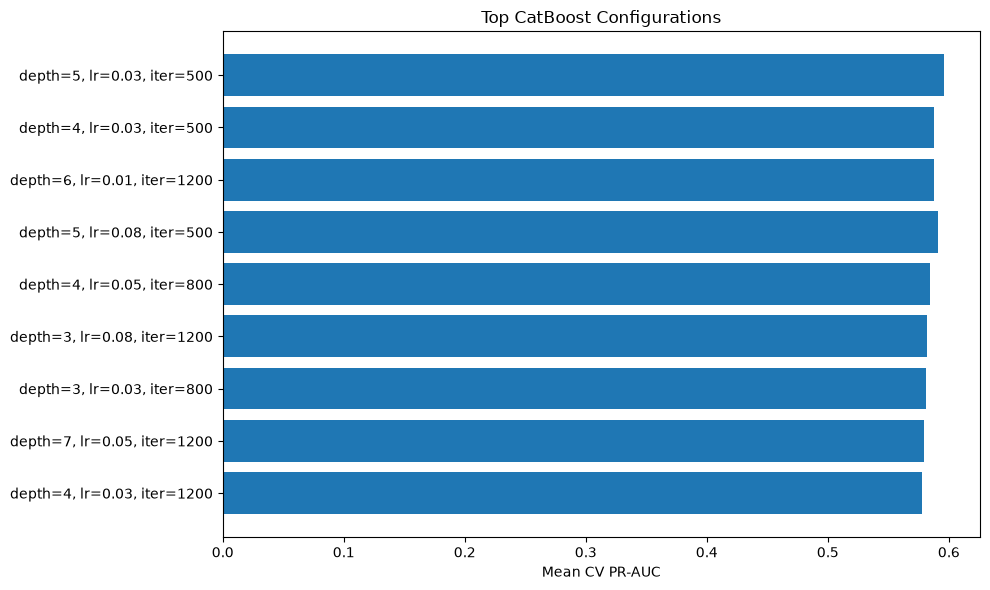

In [9]:
top_tuning = tuning_view.head(10).copy()

def configuration_label(row):
    return f"depth={row['depth']}, lr={row['learning_rate']}, iter={row['iterations']}"

top_tuning["configuration"] = top_tuning.apply(configuration_label, axis=1)
top_tuning = top_tuning.sort_values("mean_test_pr_auc")
plt.figure(figsize=(10, 6))
plt.barh(top_tuning["configuration"].astype(str), pd.to_numeric(top_tuning["mean_test_pr_auc"]))
plt.xlabel("Mean CV PR-AUC")
plt.title("Top CatBoost Configurations")
plt.tight_layout()
plt.show()

## 7. Check for Overfitting

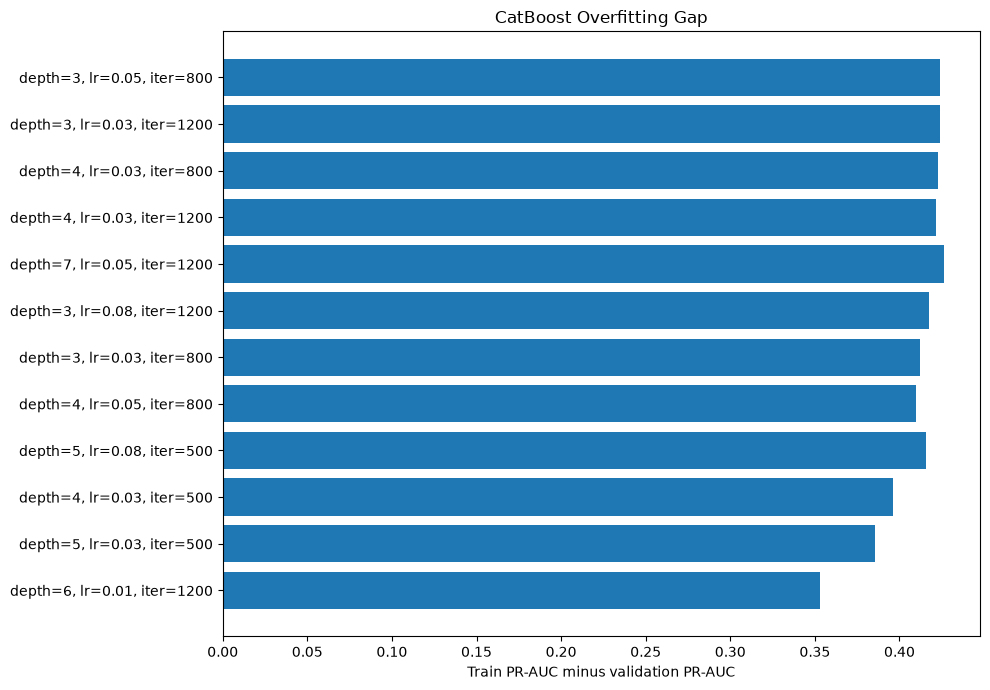

Training PR-AUC: 0.9815
Validation PR-AUC: 0.596
Overfit gap: 0.3855


In [10]:
overfit_view = tuning_view.head(15).copy()
overfit_view["configuration"] = overfit_view.apply(configuration_label, axis=1)
overfit_view = overfit_view.sort_values("overfit_gap")

plt.figure(figsize=(10, 7))
plt.barh(overfit_view["configuration"].astype(str), overfit_view["overfit_gap"])
plt.xlabel("Train PR-AUC minus validation PR-AUC")
plt.title("CatBoost Overfitting Gap")
plt.tight_layout()
plt.show()

best_search_row = tuning_view.iloc[0]
print("Training PR-AUC:", round(best_search_row["mean_train_pr_auc"], 4))
print("Validation PR-AUC:", round(best_search_row["mean_test_pr_auc"], 4))
print("Overfit gap:", round(best_search_row["overfit_gap"], 4))

## 8. Depth vs. Regularization

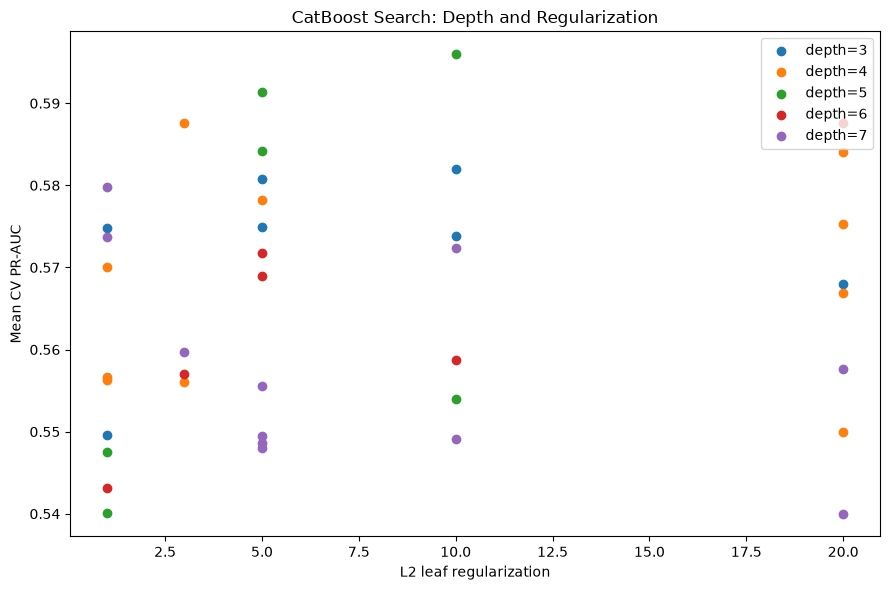

In [11]:
parameter_plot = tuning_view.copy()
parameter_plot["depth"] = pd.to_numeric(parameter_plot["depth"])
parameter_plot["l2_leaf_reg"] = pd.to_numeric(parameter_plot["l2_leaf_reg"])
parameter_plot["mean_test_pr_auc"] = pd.to_numeric(parameter_plot["mean_test_pr_auc"])

plt.figure(figsize=(9, 6))
for depth in sorted(parameter_plot["depth"].unique()):
    rows = parameter_plot[parameter_plot["depth"] == depth]
    plt.scatter(rows["l2_leaf_reg"], rows["mean_test_pr_auc"], label=f"depth={int(depth)}")
plt.xlabel("L2 leaf regularization")
plt.ylabel("Mean CV PR-AUC")
plt.title("CatBoost Search: Depth and Regularization")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Development-only early stopping

In [12]:
X_es_train, X_es_valid, y_es_train, y_es_valid = train_test_split(
    X_dev, y_dev, test_size=0.20, stratify=y_dev, random_state=RANDOM_STATE
)

def parse_class_weights(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, str):
        if value == "None":
            return None
        return [float(x) for x in ast.literal_eval(value)]
    if isinstance(value, (list, tuple, np.ndarray)):
        return [float(x) for x in value]
    return None

best_class_weights = parse_class_weights(best_search_row["class_weights"])

early_stop_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC:type=Classic",
    iterations=3000,
    learning_rate=float(best_search_row["learning_rate"]),
    depth=int(best_search_row["depth"]),
    l2_leaf_reg=float(best_search_row["l2_leaf_reg"]),
    random_strength=float(best_search_row["random_strength"]),
    bagging_temperature=float(best_search_row["bagging_temperature"]),
    border_count=int(best_search_row["border_count"]),
    class_weights=best_class_weights,
    random_seed=RANDOM_STATE,
    od_type="Iter", od_wait=75, use_best_model=True,
    verbose=False, allow_writing_files=False, thread_count=-1,
)

early_stop_model.fit(
    X_es_train, y_es_train,
    cat_features=categorical_columns,
    eval_set=(X_es_valid, y_es_valid),
)

optimal_iterations = early_stop_model.get_best_iteration() + 1
print("Random-search iterations:", int(best_search_row["iterations"]))
print("Early-stopped iterations:", optimal_iterations)

Random-search iterations: 500
Early-stopped iterations: 101


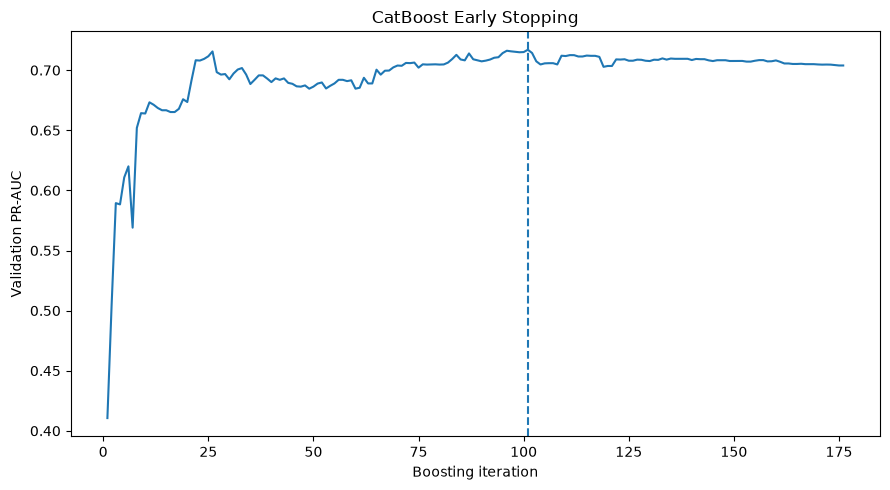

In [13]:
history = early_stop_model.get_evals_result()
validation_pr_auc = history["validation"]["PRAUC:type=Classic"]
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(validation_pr_auc) + 1), validation_pr_auc)
plt.axvline(optimal_iterations, linestyle="--")
plt.xlabel("Boosting iteration")
plt.ylabel("Validation PR-AUC")
plt.title("CatBoost Early Stopping")
plt.tight_layout()
plt.show()

## 10. Refit on all development data

In [14]:
final_params = {
    "iterations": optimal_iterations,
    "learning_rate": float(best_search_row["learning_rate"]),
    "depth": int(best_search_row["depth"]),
    "l2_leaf_reg": float(best_search_row["l2_leaf_reg"]),
    "random_strength": float(best_search_row["random_strength"]),
    "bagging_temperature": float(best_search_row["bagging_temperature"]),
    "border_count": int(best_search_row["border_count"]),
    "class_weights": best_class_weights,
}

final_model = CatBoostClassifier(
    loss_function="Logloss", eval_metric="PRAUC:type=Classic",
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
    thread_count=-1, **final_params,
)
final_model.fit(X_dev, y_dev, cat_features=categorical_columns)

CatBoostClassifier(allow_writing_files=False, bagging_temperature=1.0, border_count=64, depth=5, eval_metric='PRAUC:type=Classic', iterations=101, l2_leaf_reg=10.0, learning_rate=0.03, loss_function='Logloss', random_seed=42, random_strength=1.0, verbose=False)

## 11. Generate OOF probabilities

In [15]:
final_cv = evaluate_catboost_cv(development, params=final_params, return_oof=True)
oof_probability = final_cv["oof_probability"]
print("OOF ROC-AUC:", round(roc_auc_score(y_dev, oof_probability), 4))
print("OOF PR-AUC:", round(average_precision_score(y_dev, oof_probability), 4))

OOF ROC-AUC: 0.8009
OOF PR-AUC: 0.5628


## 12. Evaluate

In [16]:
holdout_probability = final_model.predict_proba(X_holdout)[:, 1]
holdout_prediction = (holdout_probability >= 0.50).astype(int)

metrics = pd.DataFrame([{
    "accuracy": accuracy_score(y_holdout, holdout_prediction),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, holdout_prediction),
    "precision": precision_score(y_holdout, holdout_prediction, zero_division=0),
    "recall": recall_score(y_holdout, holdout_prediction, zero_division=0),
    "f1": f1_score(y_holdout, holdout_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_holdout, holdout_probability),
    "pr_auc": average_precision_score(y_holdout, holdout_probability),
    "brier_score": brier_score_loss(y_holdout, holdout_probability),
}])
metrics.round(4)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,0.8396,0.5278,1.0,0.0556,0.1053,0.7754,0.4718,0.1192


## 13. Confusion matrix

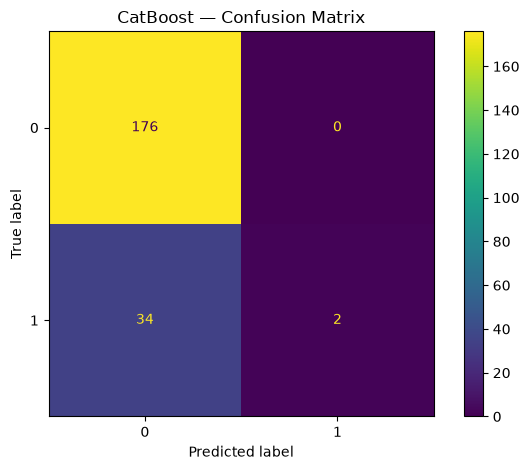

In [17]:
ConfusionMatrixDisplay.from_predictions(y_holdout, holdout_prediction)
plt.title("CatBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. ROC curve

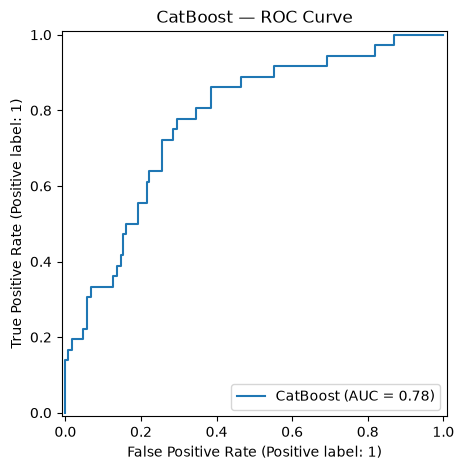

In [18]:
RocCurveDisplay.from_predictions(y_holdout, holdout_probability, name="CatBoost")
plt.title("CatBoost — ROC Curve")
plt.tight_layout()
plt.show()

## 15. Precision–Recall curve

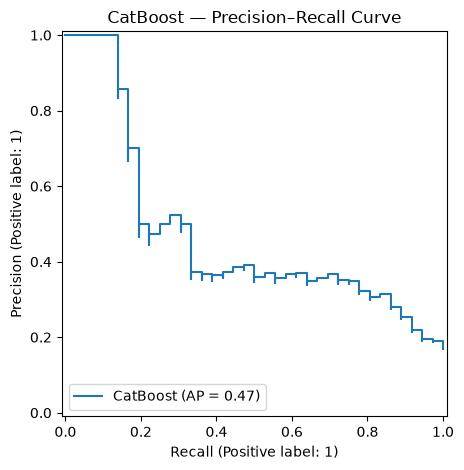

In [19]:
PrecisionRecallDisplay.from_predictions(y_holdout, holdout_probability, name="CatBoost")
plt.title("CatBoost — Precision–Recall Curve")
plt.tight_layout()
plt.show()

## 16. Predicted probability distributions

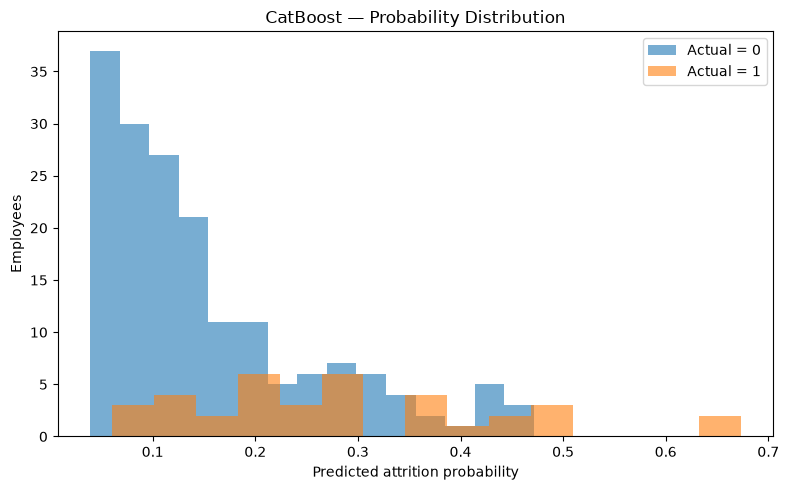

In [20]:
probability_frame = pd.DataFrame({"Actual": y_holdout.values, "Probability": holdout_probability})
plt.figure(figsize=(8, 5))
for actual_value in sorted(probability_frame["Actual"].unique()):
    values = probability_frame.loc[probability_frame["Actual"] == actual_value, "Probability"]
    plt.hist(values, bins=15, alpha=0.6, label=f"Actual = {actual_value}")
plt.xlabel("Predicted attrition probability")
plt.ylabel("Employees")
plt.title("CatBoost — Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Calibration

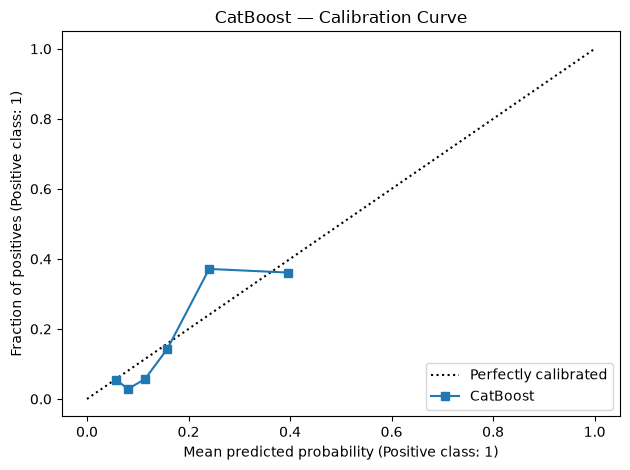

In [21]:
CalibrationDisplay.from_predictions(
    y_holdout, holdout_probability, n_bins=6, strategy="quantile", name="CatBoost"
)
plt.title("CatBoost — Calibration Curve")
plt.tight_layout()
plt.show()

## 18. Native feature importance

In [22]:
feature_importance = pd.DataFrame({
    "feature": X_dev.columns,
    "importance": final_model.get_feature_importance(),
}).sort_values("importance", ascending=False)
feature_importance.head(20)

,feature,importance
18,OverTime,17.350540
22,StockOptionLevel,8.100829
13,JobSatisfaction,7.850898
7,EnvironmentSatisfaction,5.891846
11,JobLevel,5.692797
29,YearsWithCurrManager,4.572458
15,MonthlyIncome,4.109864
23,TotalWorkingYears,4.058033
25,WorkLifeBalance,3.943356
26,YearsAtCompany,3.874130


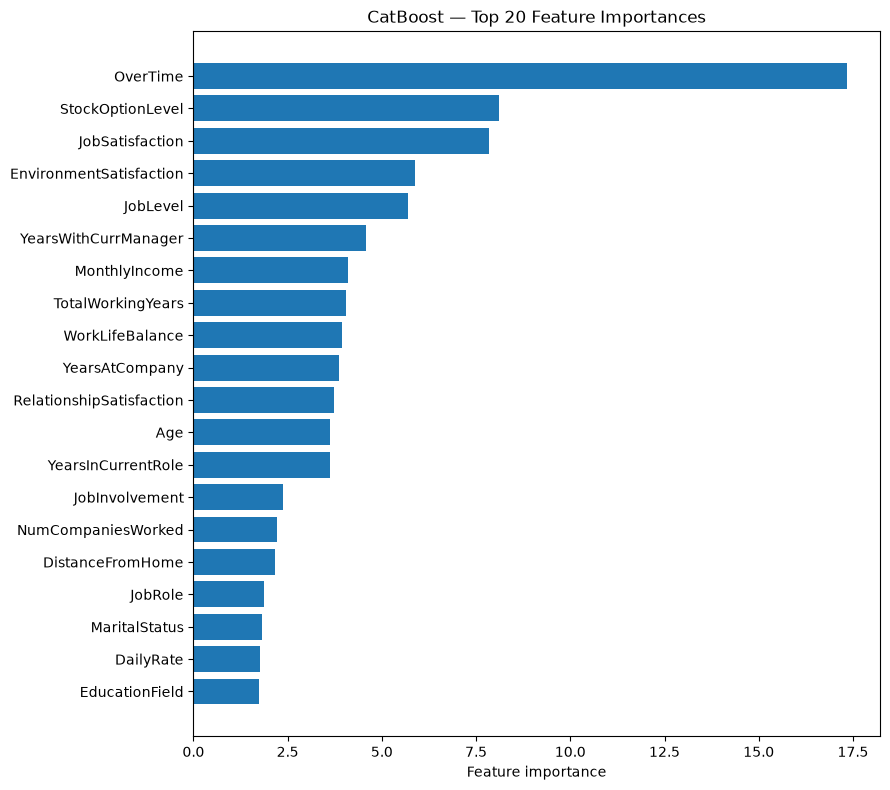

In [23]:
top_features = feature_importance.head(20).sort_values("importance")
plt.figure(figsize=(9, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.title("CatBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## 19. Compare against earlier models

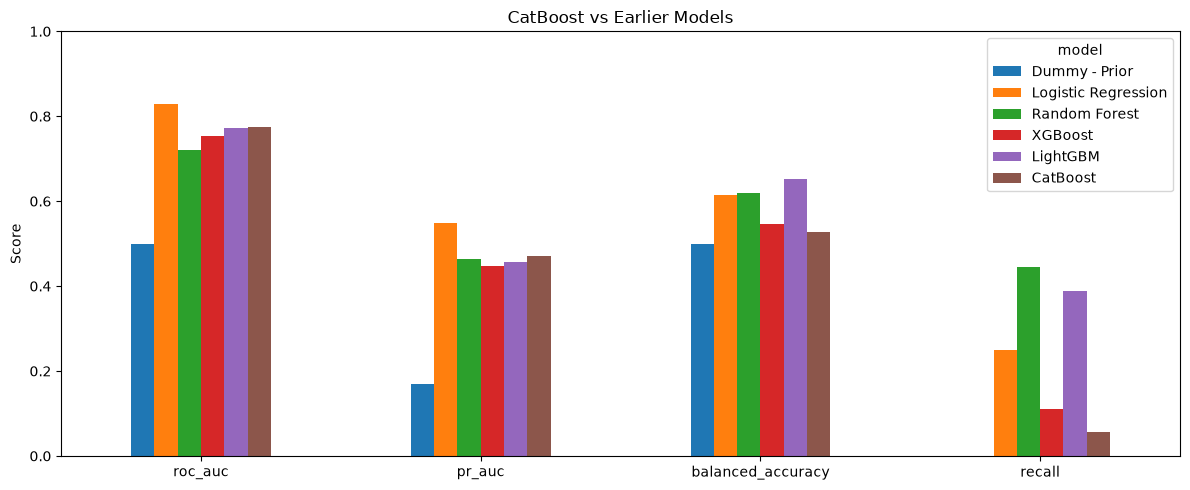

,model,roc_auc,pr_auc,balanced_accuracy,recall
0,Dummy - Prior,0.5000,0.1698,0.5000,0.0000
1,Logistic Regression,0.8278,0.5489,0.6136,0.2500
2,Random Forest,0.7194,0.4647,0.6199,0.4444
3,XGBoost,0.7539,0.4471,0.5470,0.1111
4,LightGBM,0.7730,0.4558,0.6518,0.3889
5,CatBoost,0.7754,0.4718,0.5278,0.0556


In [24]:
comparison_rows = []

baseline_path = RESULTS_DIR / "baseline_results.csv"
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    prior = baseline.loc[baseline["model"] == "Dummy - Prior"].iloc[0]
    comparison_rows.append({
        "model": "Dummy - Prior", "roc_auc": prior["roc_auc"], "pr_auc": prior["pr_auc"],
        "balanced_accuracy": prior["balanced_accuracy"], "recall": prior["recall"],
    })

for model_name, filename in {
    "Logistic Regression": "logistic_regression_results.csv",
    "Random Forest": "random_forest_results.csv",
    "XGBoost": "xgboost_results.csv",
    "LightGBM": "lightgbm_results.csv",
}.items():
    path = RESULTS_DIR / filename
    if path.exists():
        row = pd.read_csv(path).iloc[0]
        comparison_rows.append({
            "model": model_name, "roc_auc": row["roc_auc"], "pr_auc": row["pr_auc"],
            "balanced_accuracy": row["balanced_accuracy"], "recall": row["recall"],
        })

comparison_rows.append({
    "model": "CatBoost", "roc_auc": metrics["roc_auc"].iloc[0], "pr_auc": metrics["pr_auc"].iloc[0],
    "balanced_accuracy": metrics["balanced_accuracy"].iloc[0], "recall": metrics["recall"].iloc[0],
})

comparison = pd.DataFrame(comparison_rows)
comparison.set_index("model").T.plot(kind="bar", figsize=(12, 5))
plt.title("CatBoost vs Earlier Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
comparison.round(4)

## 20. Save

In [25]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

feature_comparison.to_csv(RESULTS_DIR / "catboost_feature_set_comparison.csv", index=False)
tuning_view.to_csv(RESULTS_DIR / "catboost_tuning_results.csv", index=False)

model_results = metrics.copy()
model_results.insert(0, "model", "CatBoost")
model_results["feature_set"] = selected_name
model_results["cv_pr_auc"] = final_cv["mean_test_pr_auc"]
model_results["early_stopped_iterations"] = optimal_iterations
for parameter, value in final_params.items():
    model_results[f"best_{parameter}"] = str(value)
model_results.to_csv(RESULTS_DIR / "catboost_results.csv", index=False)

pd.DataFrame({
    ID_COLUMN: development[ID_COLUMN].values, "Actual": y_dev.values,
    "OOF_AttritionProbability": oof_probability,
}).to_csv(RESULTS_DIR / "catboost_oof_predictions.csv", index=False)

pd.DataFrame({
    ID_COLUMN: holdout[ID_COLUMN].values, "Actual": y_holdout.values,
    "Predicted": holdout_prediction, "AttritionProbability": holdout_probability,
}).to_csv(RESULTS_DIR / "catboost_holdout_predictions.csv", index=False)

feature_importance.to_csv(RESULTS_DIR / "catboost_feature_importance.csv", index=False)
final_model.save_model(str(MODELS_DIR / "catboost_model.cbm"))
joblib.dump({
    "model": final_model, "categorical_columns": categorical_columns,
    "feature_columns": list(X_dev.columns),
}, MODELS_DIR / "catboost_model_bundle.joblib")

print("Results saved to:", RESULTS_DIR)
print("Model saved to:", MODELS_DIR)

Results saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
Model saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\models
